In [1]:
import random
import pandas as pd
import numpy as np

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 20
df_name = "AAPL_15min"

df = pd.read_csv(f'../datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.9 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [2]:
def build_min_vectors_by_price(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            cur_vec = []
            for j in range(i - 1, i - N, -1):
                cur_vec.append((df.iloc[j]['open'] - df.iloc[i]['open']) / df.iloc[i]['open'])
            vectors.append(cur_vec)
    return np.array(vectors)

def build_max_vectors_by_price(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_max'] or take_all:
            cur_vec = []
            for j in range(i - 1, i - N, -1):
                cur_vec.append((df.iloc[j]['open'] - df.iloc[i]['open']) / df.iloc[i]['open'])
            vectors.append(cur_vec)
    return np.array(vectors)

X_train_min = build_min_vectors_by_price(df_train, N)
X_train_max = build_max_vectors_by_price(df_train, N)
print(X_train_min.shape, X_train_max.shape)

(117, 19) (106, 19)


***Сначала случай минимумов***

**Строим векторы отношений цен для трейна**

In [3]:
X_train_min[0]

array([0.11489404, 0.11795722, 0.11926283, 0.11830873, 0.12264889,
       0.12192427, 0.1182334 , 0.12589138, 0.1289294 , 0.1280004 ,
       0.12900472, 0.12591644, 0.1295571 , 0.12792513, 0.11941348,
       0.12084463, 0.1180576 , 0.11911218, 0.11695285])

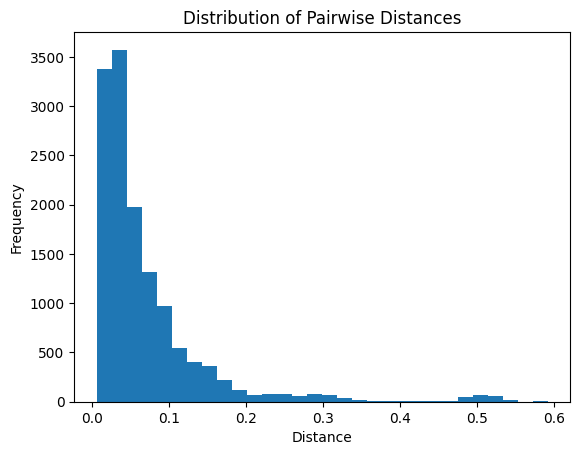

In [4]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_min)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [5]:
from sklearn.cluster import DBSCAN, KMeans

EPS = 0.05
clustering_dbscan = DBSCAN(eps=EPS, min_samples=5).fit(X_train_min)
clustering_dbscan.labels_

array([-1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,
        0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1,  0, -1,  0,  0,  0,  0,
        0,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0])

In [6]:
noise = np.where(clustering_dbscan.labels_ == -1)[0]
noise

array([ 0, 50, 58, 59, 60, 61, 63, 70, 76])

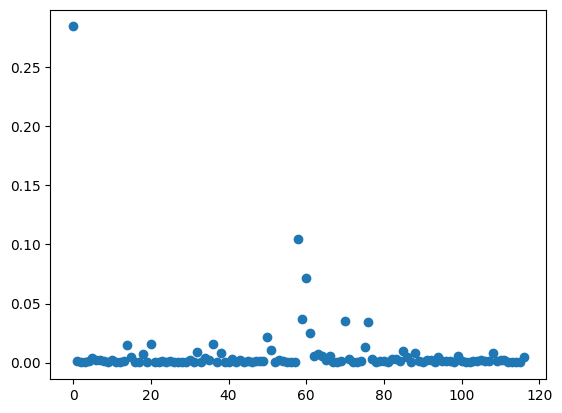

In [7]:
squared = np.diagonal(X_train_min @ X_train_min.T)
plt.scatter([i for i in range(squared.shape[0])], squared)
plt.show()

In [8]:
squared[noise]

array([0.2843914 , 0.02186996, 0.10420313, 0.03711454, 0.07164253,
       0.02542741, 0.00753174, 0.0352067 , 0.03408889])

In [9]:
clustering_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit(X_train_min)
clustering_kmeans.labels_

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [10]:
X_test = build_min_vectors_by_price(df_test, N, take_all=True)

**Проверяем DBSCAN метрики на тесте**

In [22]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering_dbscan.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering_dbscan.labels_[clustering_dbscan.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_min, X_test[i - N], EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.0112, Recall: 1.0000, Precision: 0.0051, F1 Score: 0.0102, ROC_AUC: 0.5031


**Проверяем Kmeans метрики на тесте**

In [24]:
def predict_kmeans(v, threshold=None):
    label = clustering_kmeans.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering_kmeans.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test[i - N], threshold=EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.8673, Recall: 0.6000, Precision: 0.0229, F1 Score: 0.0441, ROC_AUC: 0.7344


prediction != -1

Accuracy: 0.1327, Recall: 0.4000, Precision: 0.0024, F1 Score: 0.0047, ROC_AUC: 0.2656

prediction == -1

Accuracy: 0.8673, Recall: 0.6000, Precision: 0.0229, F1 Score: 0.0441, ROC_AUC: 0.7344

***Теперь аналогично для максимумов***

In [13]:
X_train_max[0]

array([-0.00681909, -0.0121674 , -0.00793332, -0.0075991 , -0.00534831,
       -0.0063734 , -0.00763297, -0.00971609, -0.01176628, -0.00791104,
       -0.00730936, -0.00815622, -0.00927045, -0.00885319, -0.00784419,
       -0.00802242, -0.00795556, -0.00541516, -0.00815622])

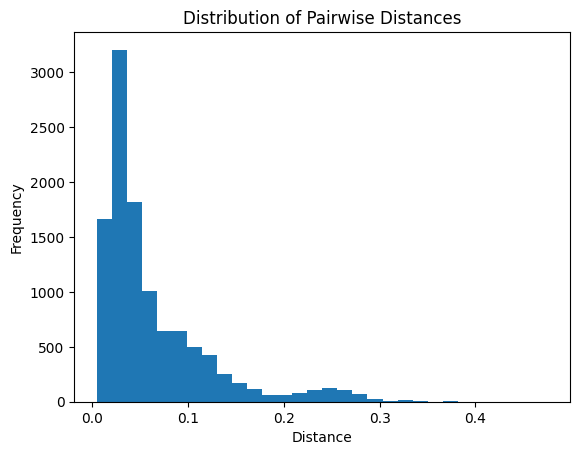

In [14]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_max)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [25]:
from sklearn.cluster import DBSCAN, KMeans

EPS = 0.05
clustering_dbscan = DBSCAN(eps=EPS, min_samples=5).fit(X_train_max)
clustering_dbscan.labels_

array([ 0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1,  0,  0,  0,
        0, -1,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0])

In [16]:
noise = np.where(clustering_dbscan.labels_ == -1)[0]
noise

array([ 2, 45, 46, 47, 52, 57, 87])

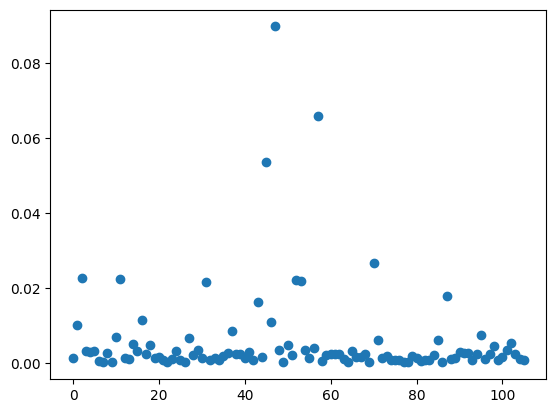

In [17]:
squared = np.diagonal(X_train_max @ X_train_max.T)
plt.scatter([i for i in range(squared.shape[0])], squared)
plt.show()

In [18]:
squared[noise]

array([0.02252906, 0.05355702, 0.0108392 , 0.08981121, 0.02216912,
       0.06578585, 0.0177977 ])

In [27]:
clustering_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit(X_train_max)
clustering_kmeans.labels_

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

**Проверяем DBSCAN метрики на тесте**

In [28]:
def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering_dbscan.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering_dbscan.labels_[clustering_dbscan.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_max, X_test[i - N], EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.0398, Recall: 1.0000, Precision: 0.0095, F1 Score: 0.0188, ROC_AUC: 0.5154


**Проверяем Kmeans метрики на тесте**

In [30]:
def predict_kmeans(v, threshold=None):
    label = clustering_kmeans.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering_kmeans.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test[i - N], threshold=EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.1429, Recall: 1.0000, Precision: 0.0106, F1 Score: 0.0210, ROC_AUC: 0.5675
